In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [24]:
!pip install seaborn -q

In [25]:
import pickle
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout
)

In [26]:
speech_features = np.load(
    "/kaggle/input/models/akiraaravind/1/pytorch/default/1/hubert_features.npy"
)

text_features = np.load(
    "/kaggle/input/models/akiraaravind/text/pytorch/default/1/bert_features.npy"
)

labels = np.load(
    "/kaggle/input/models/akiraaravind/1/pytorch/default/1/emotion_labels.npy"
)

print("Speech Shape:", speech_features.shape)

print("Text Shape:", text_features.shape)

print("Labels Shape:", labels.shape)

Speech Shape: (2800, 768)
Text Shape: (2800, 768)
Labels Shape: (2800,)


In [27]:
fusion_features = np.concatenate(
    [speech_features, text_features],
    axis=1
)

print("Fusion Shape:", fusion_features.shape)

Fusion Shape: (2800, 1536)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(

    fusion_features,
    labels,

    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Train Shape:", X_train.shape)

print("Test Shape:", X_test.shape)

Train Shape: (2240, 1536)
Test Shape: (560, 1536)


In [29]:
num_classes = len(np.unique(labels))

model = Sequential([

    Dense(
        512,
        activation='relu',
        input_shape=(1536,)
    ),

    Dropout(0.4),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.4),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        num_classes,
        activation='softmax'
    )
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 952,071 (3.63 MB)

 Trainable params: 952,071 (3.63 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_test,
        y_test
    ),

    epochs=20,
    batch_size=32
)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1629 - loss: 2.0113 - val_accuracy: 0.2250 - val_loss: 1.8662
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3313 - loss: 1.6724 - val_accuracy: 0.5768 - val_loss: 1.2395
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5549 - loss: 1.0543 - val_accuracy: 0.7786 - val_loss: 0.5841
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6893 - loss: 0.7393 - val_accuracy: 0.8929 - val_loss: 0.3610
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7603 - loss: 0.5811 - val_accuracy: 0.9357 - val_loss: 0.2700
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8219 - loss: 0.4559 - val_accuracy: 0.9625 - val_loss: 0.1463
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8571 - loss: 0.3531 - val_accuracy: 0.9661 - val_loss: 0.1177
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8696 - loss: 0.3319 - val_accuracy: 0.9750 - val_loss

In [31]:
y_pred_probs = model.predict(X_test)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Fusion Accuracy:", accuracy)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        digits=6
    )
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Fusion Accuracy: 0.9928571428571429

Classification Report:

              precision    recall  f1-score   support

           0   1.000000  1.000000  1.000000        80
           1   0.987654  1.000000  0.993789        80
           2   1.000000  0.987500  0.993711        80
           3   0.975610  1.000000  0.987654        80
           4   1.000000  0.987500  0.993711        80
           5   1.000000  0.975000  0.987342        80
           6   0.987654  1.000000  0.993789        80

    accuracy                       0.992857       560
   macro avg   0.992988  0.992857  0.992856       560
weighted avg   0.992988  0.992857  0.992856       560



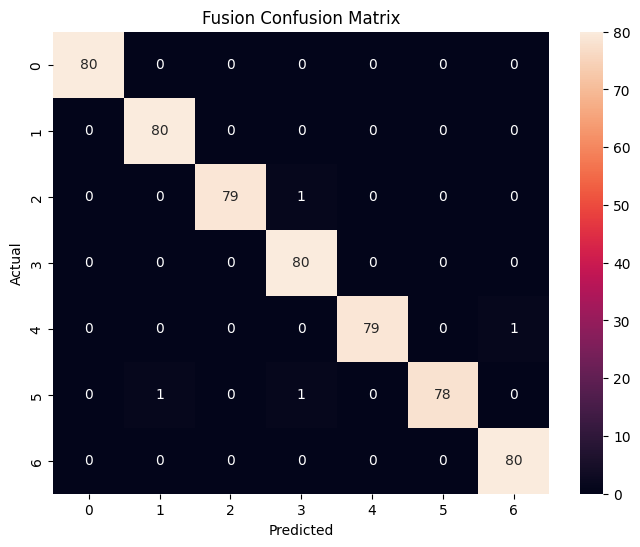

In [32]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Fusion Confusion Matrix")

plt.show()

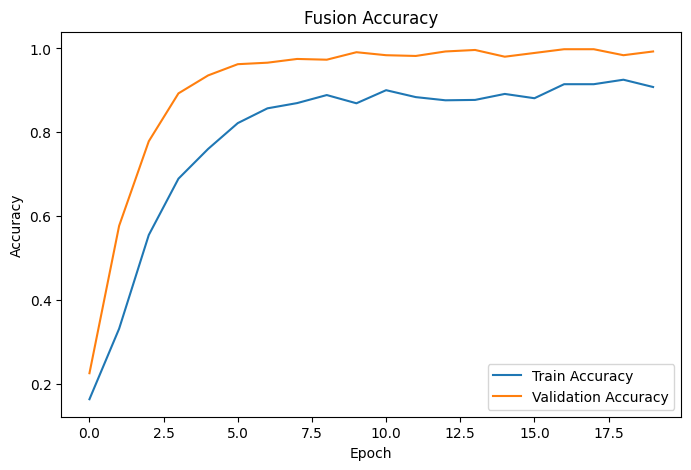

In [33]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Fusion Accuracy")

plt.legend()

plt.show()

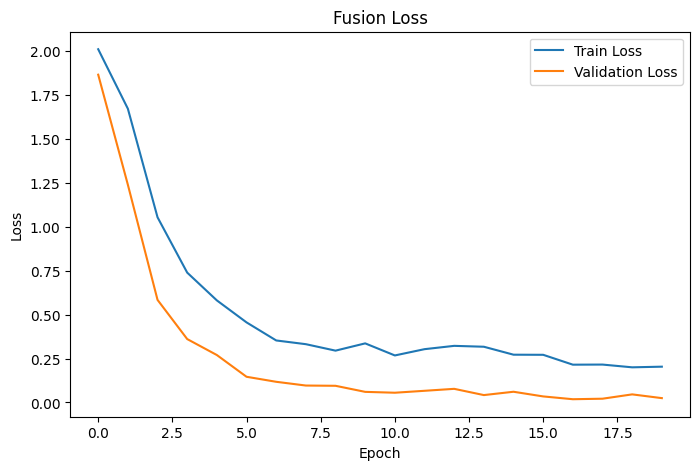

In [34]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Fusion Loss")

plt.legend()

plt.show()

In [35]:
model.save(
    "fusion_emotion_model.h5"
)

print("Fusion Model Saved")

Fusion Model Saved


In [36]:
model = tf.keras.models.load_model(
    "fusion_emotion_model.h5"
)

print("Fusion Model Loaded")

Fusion Model Loaded


In [37]:
emotion_labels = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "pleasant_surprise",
    "sad"
]

In [38]:
'''
speech_emb = np.load(
    "/kaggle/input/yourtest/speech_test_embedding.npy"
)

text_emb = np.load(
    "/kaggle/input/yourtest/text_test_embedding.npy"
)
'''

'\nspeech_emb = np.load(\n    "/kaggle/input/yourtest/speech_test_embedding.npy"\n)\n\ntext_emb = np.load(\n    "/kaggle/input/yourtest/text_test_embedding.npy"\n)\n'